# PV System Analysis — Čelákovice

Data visualization project for NDBI042 (Charles University).  
Analyzes a residential solar system (9.45 kWp, 14.4 kWh battery) over 2022–2026.

**This notebook:** simple exploratory charts + data export for D3.js visualizations.  
**D3 dashboard:** open `d3/index.html` via a local HTTP server.

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import json
from pathlib import Path

DATA_DIR = Path('Data')
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

PANEL_AREA_M2 = 42
KJ_TO_WH = 1 / 3.6
FIRST_YEAR = 2022

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 13,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

## 1 · Data Loading

### 1a · Zatez Excel files

Each yearly file contains a single sheet (`Přehled`) with three embedded tables (monthly / daily / hourly) identified by their header rows.

In [96]:
MONTHLY_HDR = ['Měsíc', 'Zátěž [kWh]', 'Síť [kWh]', 'Výkon FVE [kWh]']
DAILY_HDR   = ['Den',   'Zátěž [Wh]',  'Síť [Wh]',  'Výkon FVE [Wh]']
HOURLY_HDR  = ['Čas',   'Zátěž [Wh]',  'Síť [Wh]',  'Výkon FVE [Wh]']

def find_table_start(df, header):
    """Return row index of header row, or -1 if not found."""
    for i in range(len(df)):
        if df.iloc[i, :len(header)].tolist() == header:
            return i
    return -1

def extract_tables(path):
    """Return (monthly_df, daily_df) extracted from a Zatez Excel file."""
    raw = pd.read_excel(path, sheet_name='Přehled', header=None)
    hdrs   = [MONTHLY_HDR, DAILY_HDR, HOURLY_HDR]
    starts = [find_table_start(raw, h) for h in hdrs]

    tables = []
    for i, (hdr, start) in enumerate(zip(hdrs, starts)):
        if start == -1:
            print(f'  WARNING: table {i} not found in {path.name}')
            tables.append(None)
            continue
        end = next((s for s in starts[i+1:] if s != -1), len(raw))
        tbl = raw.iloc[start+1:end].copy()
        col_names = [str(v) if pd.notna(v) else f'_x{j}'
                     for j, v in enumerate(raw.iloc[start].tolist())]
        tbl.columns = col_names
        tbl = tbl[[c for c in hdr if c in tbl.columns]].dropna(how='all').copy()
        for col in hdr[1:]:
            tbl[col] = pd.to_numeric(tbl[col], errors='coerce')
        tables.append(tbl)
    return tables

monthly_parts, daily_parts = [], []
for year in range(FIRST_YEAR, 2027):
    path = DATA_DIR / f'Zatez{year}.xlsx'
    if not path.exists():
        continue
    print(f'Loading {path.name} ...')
    tbls = extract_tables(path)
    if tbls[0] is not None:
        monthly_parts.append(tbls[0])
    if tbls[1] is not None:
        daily_parts.append(tbls[1])

monthly_energy = pd.concat(monthly_parts, ignore_index=True)
daily_energy   = pd.concat(daily_parts,   ignore_index=True)

# dayfirst=True: interpret DD/MM/YYYY correctly (Czech date format)
monthly_energy['Měsíc'] = pd.to_datetime(monthly_energy['Měsíc'], dayfirst=True, errors='coerce')
daily_energy['Den']     = pd.to_datetime(daily_energy['Den'],     dayfirst=True, errors='coerce')
monthly_energy.dropna(subset=['Měsíc'], inplace=True)
daily_energy.dropna(subset=['Den'], inplace=True)

print(f'\nMonthly records : {len(monthly_energy)}')
print(f'Daily records   : {len(daily_energy)}')
print(f'Daily date range: {daily_energy["Den"].min().date()} → {daily_energy["Den"].max().date()}')
monthly_energy.tail(6)

Loading Zatez2022.xlsx ...
Loading Zatez2023.xlsx ...
Loading Zatez2024.xlsx ...
Loading Zatez2025.xlsx ...
Loading Zatez2026.xlsx ...

Monthly records : 50
Daily records   : 1482
Daily date range: 2022-04-05 → 2026-05-18


C:\Users\pepal\AppData\Local\Temp\ipykernel_9844\1032642009.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  monthly_energy['Měsíc'] = pd.to_datetime(monthly_energy['Měsíc'], dayfirst=True, errors='coerce')


,Měsíc,Zátěž [kWh],Síť [kWh],Výkon FVE [kWh]
44,2025-12-01,531,416,222
45,2026-01-01,519,383,254
46,2026-02-01,470,140,439
47,2026-03-01,555,-220,945
48,2026-04-01,568,-658,1407
49,2026-05-01,321,-410,852


### 1b · Weather data (CHMI)

- **Irradiation:** Praha Karlov station (11519), ~10 km from Čelákovice — `RGLB_D` daily global radiation sum [kJ/m²]
- **Temperature:** Brandýs nad Labem station (11563), ~7 km from Čelákovice — `TPM` mean daily temperature [°C]

In [97]:
def load_chmi(path, value_name):
    df = pd.read_csv(path, usecols=['DT', 'VALUE'])
    df['Date']  = pd.to_datetime(df['DT'].str[:10])
    df = df.rename(columns={'VALUE': value_name})
    df = df[df['Date'].dt.year >= FIRST_YEAR]
    return df[['Date', value_name]].dropna(subset=[value_name]).reset_index(drop=True)

irradiation = load_chmi(
    DATA_DIR / 'dly-0-20000-0-11519-RGLB_D.csv',
    'Irradiation [kJ/m2]'
)
temperature = load_chmi(
    DATA_DIR / 'dly-0-203-0-11563-TPM.csv',
    'Temperature [C]'
)

print(f'Irradiation : {irradiation["Date"].min().date()} → {irradiation["Date"].max().date()}  ({len(irradiation)} days)')
print(f'Temperature : {temperature["Date"].min().date()} → {temperature["Date"].max().date()}  ({len(temperature)} days)')
irradiation.head(3)

Irradiation : 2022-01-01 → 2025-12-31  (1461 days)
Temperature : 2022-01-01 → 2025-12-31  (1461 days)


,Date,Irradiation [kJ/m2]
0,2022-01-01,1684.0
1,2022-01-02,2251.0
2,2022-01-03,3339.0


## 2 · Efficiency Calculation

Converts irradiation from kJ/m² to Wh received on the full panel area, then expresses production as a percentage of that.

In [98]:
# Join daily production with irradiation — exclude 2022 (system not fully grid-connected)
eff = daily_energy.merge(
    irradiation.rename(columns={'Date': 'Den'}),
    on='Den', how='inner'
)
eff = eff[eff['Den'].dt.year > 2022].copy()

# Only days with real production and irradiation
eff = eff[(eff['Výkon FVE [Wh]'] > 0) & (eff['Irradiation [kJ/m2]'] > 0)].copy()

eff['Received [Wh]']  = eff['Irradiation [kJ/m2]'] * KJ_TO_WH * PANEL_AREA_M2
eff['Efficiency [%]'] = (eff['Výkon FVE [Wh]'] / eff['Received [Wh]']) * 100

# Drop physically impossible values
eff = eff[(eff['Efficiency [%]'] > 0) & (eff['Efficiency [%]'] < 100)].copy()

print(f'Efficiency records  : {len(eff)}')
print(f'Mean efficiency     : {eff["Efficiency [%]"].mean():.2f} %')
eff[['Den', 'Výkon FVE [Wh]', 'Irradiation [kJ/m2]', 'Efficiency [%]']].head()

Efficiency records  : 1073
Mean efficiency     : 24.11 %


,Den,Výkon FVE [Wh],Irradiation [kJ/m2],Efficiency [%]
267,2023-01-01,11964,2728.0,37.591119
268,2023-01-02,14526,3450.0,36.089441
269,2023-01-03,9849,2757.0,30.620239
270,2023-01-04,5440,1572.0,29.661941
271,2023-01-05,13059,3161.0,35.411036


## 3 · Visualizations

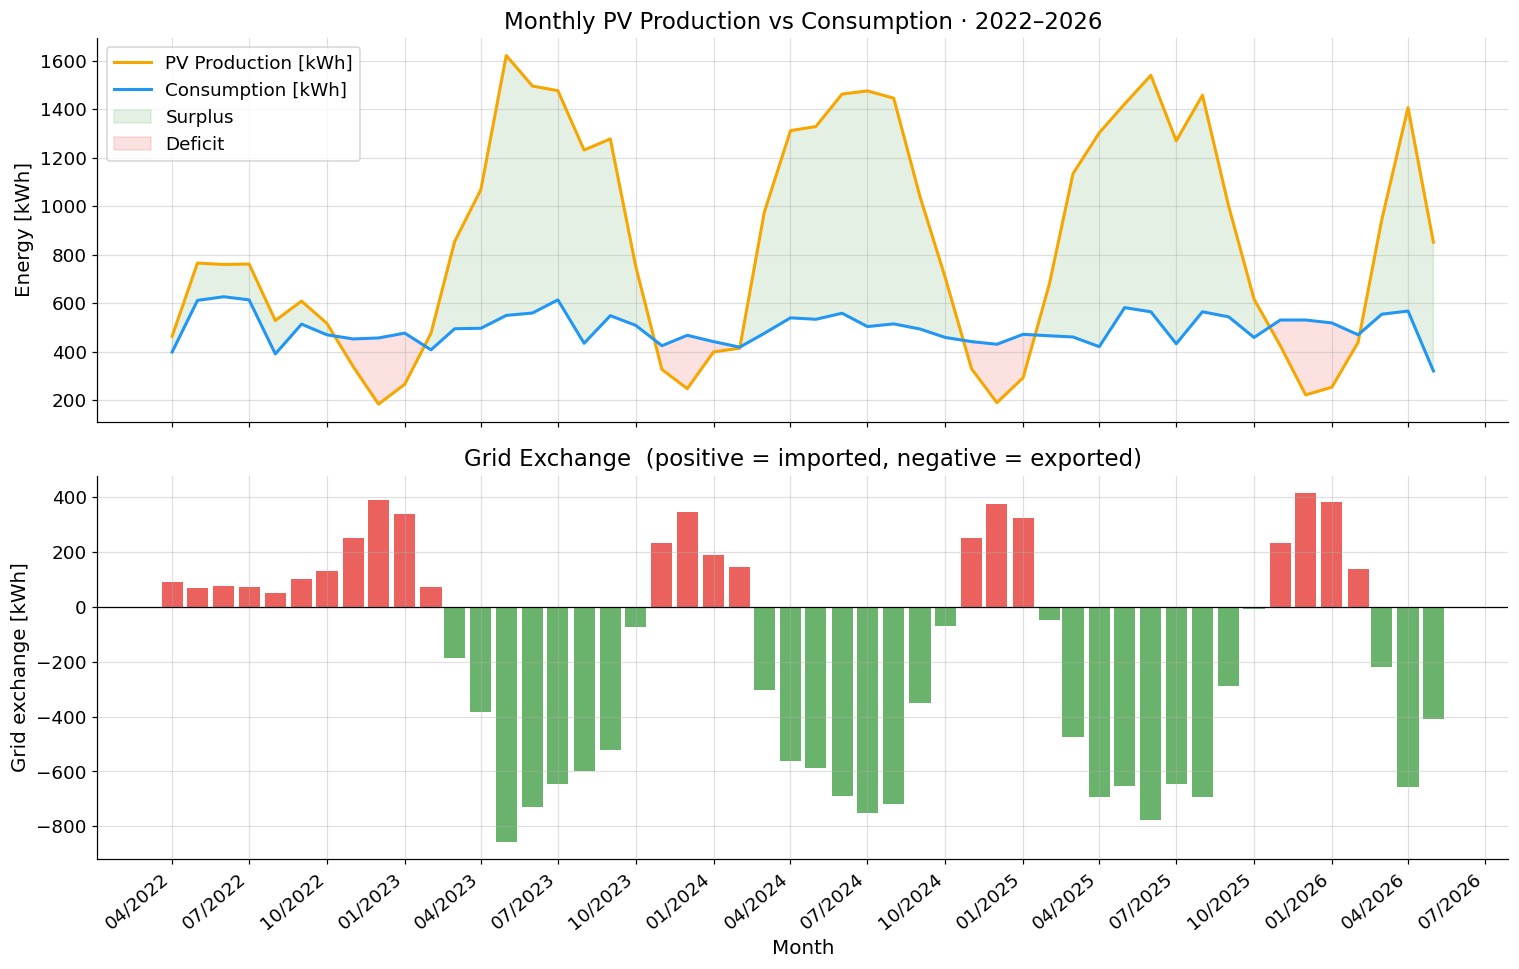

In [99]:
# ── Fig 1 · Monthly production vs consumption ─────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

me = monthly_energy.sort_values('Měsíc')

# Top panel: production & consumption
ax = axes[0]
ax.plot(me['Měsíc'], me['Výkon FVE [kWh]'],
        color='#F7A600', lw=2, label='PV Production [kWh]')
ax.plot(me['Měsíc'], me['Zátěž [kWh]'],
        color='#2196F3', lw=2, label='Consumption [kWh]')
ax.fill_between(me['Měsíc'], me['Výkon FVE [kWh]'], me['Zátěž [kWh]'],
                where=me['Výkon FVE [kWh]'] >= me['Zátěž [kWh]'],
                interpolate=True,
                color='#43A047', alpha=0.15, label='Surplus')
ax.fill_between(me['Měsíc'], me['Výkon FVE [kWh]'], me['Zátěž [kWh]'],
                where=me['Výkon FVE [kWh]'] < me['Zátěž [kWh]'],
                interpolate=True,
                color='#E53935', alpha=0.15, label='Deficit')
ax.set_ylabel('Energy [kWh]')
ax.set_title('Monthly PV Production vs Consumption · 2022–2026')
ax.legend(loc='upper left')

# Bottom panel: grid exchange
ax2 = axes[1]
colors = ['#E53935' if v > 0 else '#43A047' for v in me['Síť [kWh]']]
ax2.bar(me['Měsíc'], me['Síť [kWh]'], width=25, color=colors, alpha=0.8)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('Grid exchange [kWh]')
ax2.set_xlabel('Month')
ax2.set_title('Grid Exchange  (positive = imported, negative = exported)')

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=40, ha='right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1_monthly_overview.png', bbox_inches='tight')
plt.show()

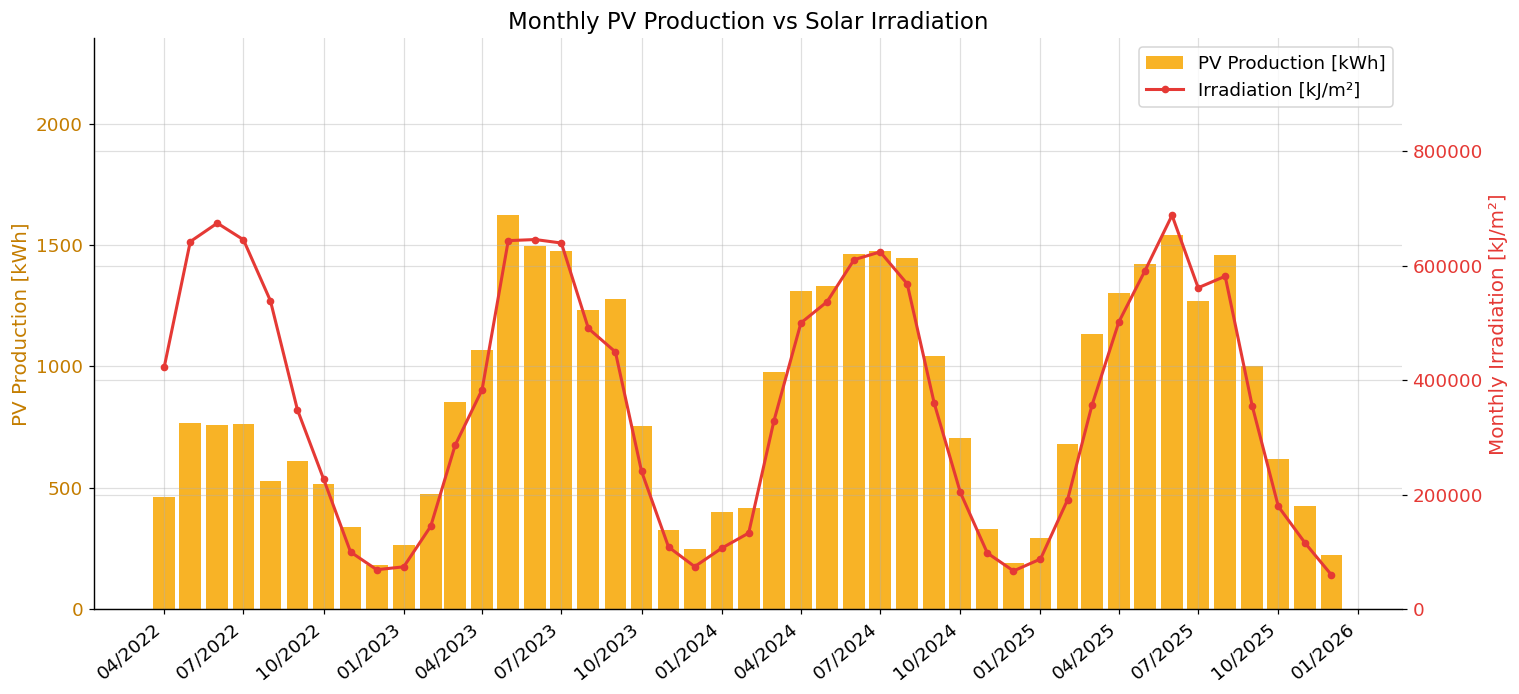

In [100]:
# ── Fig 2 · Monthly production vs irradiation ─────────────────────────────────
irr_m = irradiation.copy()
irr_m['Month'] = irr_m['Date'].dt.to_period('M').dt.to_timestamp()
irr_m = irr_m.groupby('Month')['Irradiation [kJ/m2]'].sum().reset_index()

prod_irr = me.merge(
    irr_m.rename(columns={'Month': 'Měsíc'}),
    on='Měsíc', how='inner'
)

fig, ax1 = plt.subplots(figsize=(14, 6.5))
ax1.bar(prod_irr['Měsíc'], prod_irr['Výkon FVE [kWh]'],
        width=25, color='#F7A600', alpha=0.85, label='PV Production [kWh]')
ax1.set_ylabel('PV Production [kWh]', color='#c47d00')
ax1.tick_params(axis='y', labelcolor='#c47d00')
ax1.set_ylim(0, prod_irr['Výkon FVE [kWh]'].max() * 1.45)

ax2 = ax1.twinx()
ax2.plot(prod_irr['Měsíc'], prod_irr['Irradiation [kJ/m2]'],
         color='#E53935', lw=2, marker='o', ms=4, label='Irradiation [kJ/m²]')
ax2.set_ylabel('Monthly Irradiation [kJ/m²]', color='#E53935')
ax2.tick_params(axis='y', labelcolor='#E53935')
ax2.set_ylim(0, prod_irr['Irradiation [kJ/m2]'].max() * 1.45)

ax1.set_title('Monthly PV Production vs Solar Irradiation')
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=40, ha='right')

lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc='upper right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2_production_vs_irradiation.png', bbox_inches='tight')
plt.show()

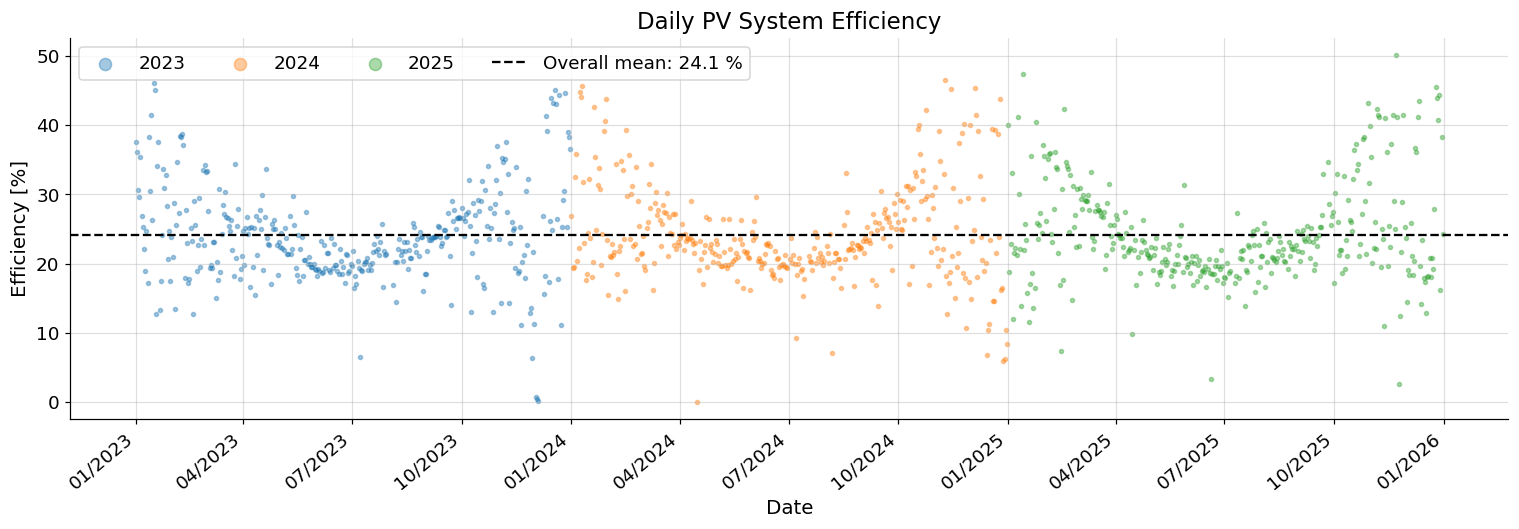

In [101]:
# ── Fig 3 · Daily efficiency timeline ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

years = sorted(eff['Den'].dt.year.unique())
cmap  = plt.cm.tab10

for i, year in enumerate(years):
    mask = eff['Den'].dt.year == year
    ax.scatter(eff.loc[mask, 'Den'], eff.loc[mask, 'Efficiency [%]'],
               s=7, alpha=0.4, color=cmap(i), label=str(year))

mean_eff = eff['Efficiency [%]'].mean()
ax.axhline(mean_eff, color='black', ls='--', lw=1.5,
           label=f'Overall mean: {mean_eff:.1f} %')

ax.set_ylabel('Efficiency [%]')
ax.set_xlabel('Date')
ax.set_title('Daily PV System Efficiency')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=40, ha='right')
ax.legend(markerscale=3, ncol=len(years)+1)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3_daily_efficiency.png', bbox_inches='tight')
plt.show()

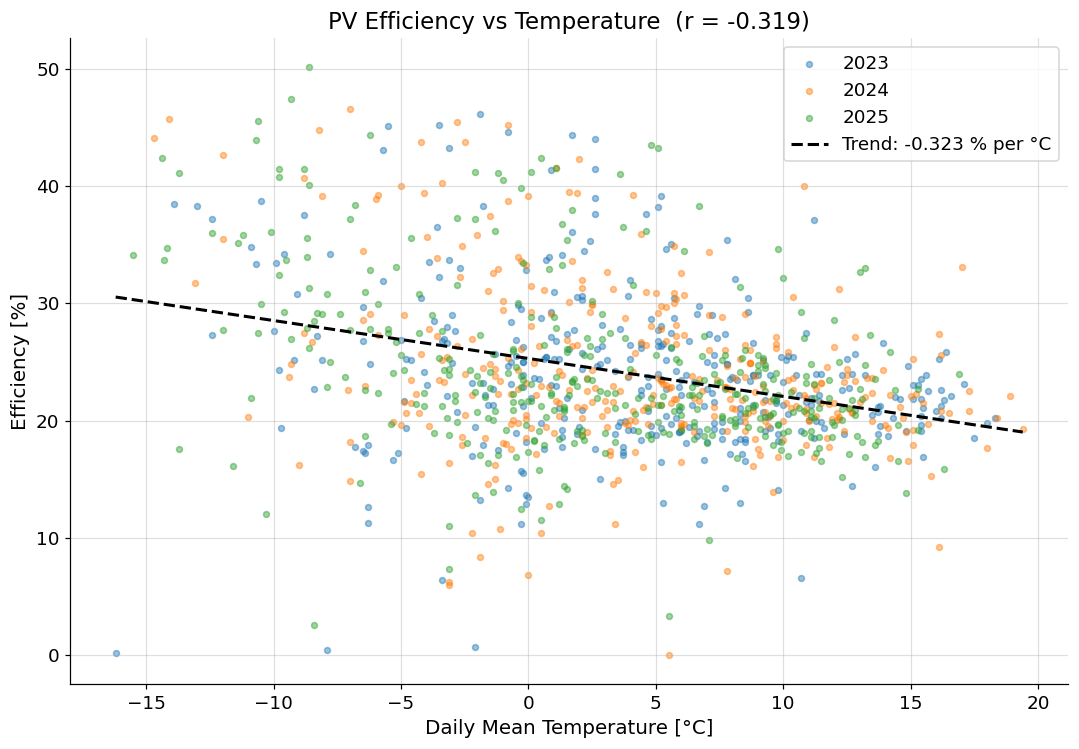

r = -0.3191,  slope = -0.3234 % / °C


In [102]:
# ── Fig 4 · Temperature vs efficiency ─────────────────────────────────────────
eff_temp = eff.merge(
    temperature.rename(columns={'Date': 'Den'}),
    on='Den', how='inner'
)

fig, ax = plt.subplots(figsize=(10, 7))

years = sorted(eff_temp['Den'].dt.year.unique())
for i, year in enumerate(years):
    mask = eff_temp['Den'].dt.year == year
    ax.scatter(eff_temp.loc[mask, 'Temperature [C]'],
               eff_temp.loc[mask, 'Efficiency [%]'],
               s=15, alpha=0.45, color=plt.cm.tab10(i), label=str(year))

# Overall linear trend
x = eff_temp['Temperature [C]'].values
y = eff_temp['Efficiency [%]'].values
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
xl = np.linspace(x.min(), x.max(), 100)
ax.plot(xl, p(xl), 'k--', lw=2, label=f'Trend: {z[0]:+.3f} % per °C')

r = np.corrcoef(x, y)[0, 1]
ax.set_xlabel('Daily Mean Temperature [°C]')
ax.set_ylabel('Efficiency [%]')
ax.set_title(f'PV Efficiency vs Temperature  (r = {r:.3f})')
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig4_efficiency_vs_temperature.png', bbox_inches='tight')
plt.show()
print(f'r = {r:.4f},  slope = {z[0]:+.4f} % / °C')

## 4 · D3.js Data Export

Exports processed data to `d3/data/` for the interactive visualizations:
- `daily_production.json` → calendar heatmap
- `energy_flow.json` → Sankey diagram

## 5 · ROI Analysis

Compares the **actual electricity cost** (with PV + virtual battery) against the **hypothetical cost**
(same consumption, no PV — everything imported from the grid at full price).

**Pricing model:**
- **2022** — no VB credits yet (system just installed, vb_export = 0): grid imports billed at full `import_czk_kwh`
- **2023–2026** — annual exports ≫ imports every year, so VB account always has credits: all grid imports drawn from virtual battery at `virtual_battery_czk_kwh` (regulated component only, commodity is free)
- VB monthly service fee added in all years
- Net investment: **391 108 Kč** (596 108 Kč total − 205 000 Kč subsidy)

In [103]:
INVESTMENT_CZK = 391_108   # after subsidy

prices = pd.read_csv('prices2022-2026.csv', comment='#')
prices['year'] = prices['year'].astype(int)

# ── per-month breakdown ────────────────────────────────────────────────────────
me_roi = monthly_energy.sort_values('Měsíc').copy()
me_roi['year']            = me_roi['Měsíc'].dt.year
me_roi['grid_import_kwh'] = me_roi['Síť [kWh]'].clip(lower=0)
me_roi['vb_export_kwh']   = (-me_roi['Síť [kWh]']).clip(lower=0)

# ── annual aggregation ─────────────────────────────────────────────────────────
annual = me_roi.groupby('year').agg(
    consumption_kwh = ('Zátěž [kWh]',   'sum'),
    grid_import_kwh = ('grid_import_kwh','sum'),
    vb_export_kwh   = ('vb_export_kwh',  'sum'),
    months          = ('Měsíc',          'count'),
).reset_index()

annual = annual.merge(prices, on='year', how='left')

# VB credits actually usable: can't draw back more than exported OR more than imported
annual['vb_drawback_kwh'] = np.minimum(annual['vb_export_kwh'], annual['grid_import_kwh'])

# Annual VB fee (proportional to months with data)
annual['vb_fee_czk'] = annual['months'] * annual['vb_monthly_fee_czk']

# ── costs ──────────────────────────────────────────────────────────────────────
annual['cost_without_pv_czk'] = annual['consumption_kwh'] * annual['import_czk_kwh']

annual['cost_with_pv_czk'] = (
    (annual['grid_import_kwh'] - annual['vb_drawback_kwh']) * annual['import_czk_kwh']
    + annual['vb_drawback_kwh'] * annual['virtual_battery_czk_kwh']
    + annual['vb_fee_czk']
)

annual['saving_czk']    = annual['cost_without_pv_czk'] - annual['cost_with_pv_czk']
annual['cum_saving_czk'] = annual['saving_czk'].cumsum()

print(annual[['year','months','consumption_kwh','grid_import_kwh','vb_export_kwh',
              'vb_drawback_kwh','cost_without_pv_czk','cost_with_pv_czk',
              'saving_czk','cum_saving_czk']].to_string(index=False))

 year  months  consumption_kwh  grid_import_kwh  vb_export_kwh  vb_drawback_kwh  cost_without_pv_czk  cost_with_pv_czk  saving_czk  cum_saving_czk
 2022       9             4537             1238              0                0             29581.24          11883.26    17697.98        17697.98
 2023      12             5987              989           3994              989             48913.79           7772.08    41141.71        58839.69
 2024      12             5815              962           4028              962             44659.20           5599.26    39059.94        97899.63
 2025      12             6030              974           4275              974             45104.40          10444.12    34660.28       132559.91
 2026       5             2433              523           1288              523             16082.13           5198.25    10883.88       143443.79


In [ ]:
# ── Fig 5a · Daily cost: actual vs hypothetical (two curves) ──────────────────
# 2022: no VB credits → paid full import_czk_kwh for grid imports
# 2023+: exports >> imports every year → all grid imports are VB drawbacks
#        → paid only virtual_battery_czk_kwh (regulated, no commodity)

daily_roi = daily_energy.copy()
daily_roi['year'] = daily_roi['Den'].dt.year
daily_roi = daily_roi.merge(
    prices[['year', 'import_czk_kwh', 'virtual_battery_czk_kwh', 'vb_monthly_fee_czk']],
    on='year', how='left'
).sort_values('Den')

daily_roi['grid_import_wh'] = daily_roi['Síť [Wh]'].clip(lower=0)
daily_roi['vb_daily_fee']   = daily_roi['vb_monthly_fee_czk'] / 30

daily_roi['effective_price'] = np.where(
    daily_roi['year'] == 2022,
    daily_roi['import_czk_kwh'],
    daily_roi['virtual_battery_czk_kwh']
)

daily_roi['cost_hypo_czk']   = daily_roi['Zátěž [Wh]'] / 1000 * daily_roi['import_czk_kwh']
daily_roi['cost_actual_czk'] = (
    daily_roi['grid_import_wh'] / 1000 * daily_roi['effective_price']
    + daily_roi['vb_daily_fee']
).clip(upper=daily_roi['cost_hypo_czk'])

x             = daily_roi['Den']
actual_smooth = daily_roi['cost_actual_czk'].rolling(30, center=True, min_periods=1).mean()
hypo_smooth   = daily_roi['cost_hypo_czk'].rolling(30,   center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(x, hypo_smooth,   color='#C62828', lw=2, label='Hypothetical cost (no PV, full import price)')
ax.plot(x, actual_smooth, color='#43A047', lw=2, label='Actual cost (VB drawback price + VB fee)')
ax.fill_between(x, actual_smooth, hypo_smooth, color='#F7A600', alpha=0.25, label='Savings')

# Year labels placed just above the top spine — no overlap with legend
xform = ax.get_xaxis_transform()
for yr in sorted(daily_roi['year'].unique()):
    vline = pd.Timestamp(yr, 1, 1)
    if vline > x.min():
        ax.axvline(vline, color='#bbb', lw=1.0, ls=':', zorder=1)
    mid = pd.Timestamp(yr, 6, 15)
    if x.min() <= mid <= x.max():
        ax.text(mid, 1.02, str(yr),
                ha='center', fontsize=14, color='#444', fontweight='bold',
                transform=xform)

ax.set_ylabel('Daily electricity cost [CZK]  (30-day rolling mean)', fontsize=15)
ax.set_title('Daily Electricity Cost — Actual vs. Hypothetical Without PV', fontsize=17, pad=22)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 3, 5, 7, 9, 11]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right', fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.set_xlim(x.min(), x.max() + pd.DateOffset(days=7))
ax.set_ylim(0, hypo_smooth.max() * 1.10)
ax.legend(loc='upper left', fontsize=13)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig5a_daily_cost.png', bbox_inches='tight')
plt.show()

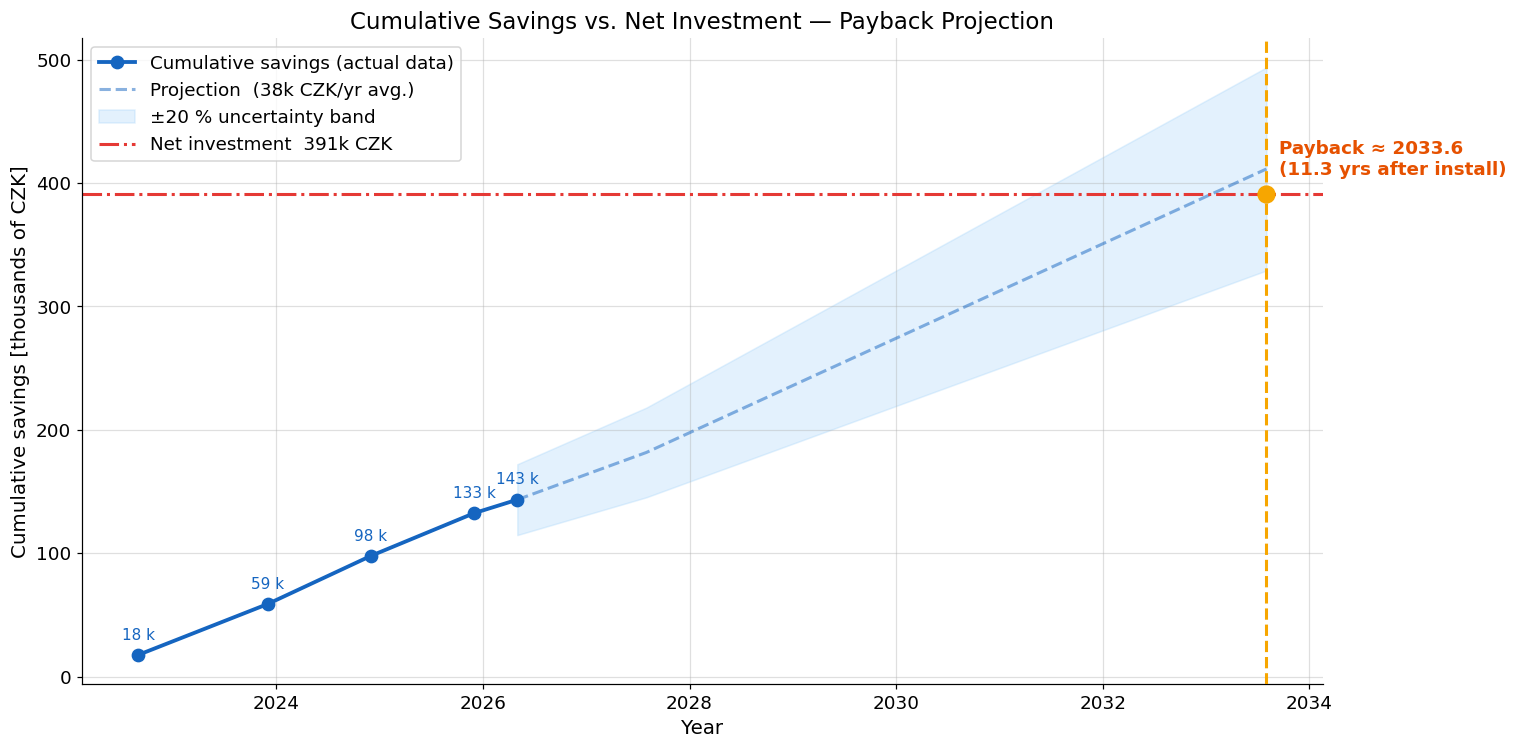


Avg annual saving (2023–2025): 38,287 CZK
Payback year: 2033.6  =  11.3 years after installation


In [143]:
# ── Fig 5b · Cumulative savings vs investment — payback projection ─────────────
full_years       = annual[annual['months'] == 12]
avg_annual_saving = full_years['saving_czk'].mean()

last_year   = annual['year'].max()
last_cum    = annual['cum_saving_czk'].iloc[-1]
last_months = annual.loc[annual['year'] == last_year, 'months'].values[0]

proj_years, proj_cum = [], []
y, c = last_year + (12 - last_months) / 12, last_cum
for _ in range(30):
    y += 1
    c += avg_annual_saving
    proj_years.append(y)
    proj_cum.append(c)
    if c >= INVESTMENT_CZK * 1.05:
        break

payback_year = next((y for y, c in zip(proj_years, proj_cum) if c >= INVESTMENT_CZK), None)

fig, ax = plt.subplots(figsize=(14, 7))

# ── historical cumulative savings ──────────────────────────────────────────────
hist_x = annual['year'] + (annual['months'] - 1) / 12
ax.plot(hist_x, annual['cum_saving_czk'] / 1000,
        'o-', color='#1565C0', lw=2.5, ms=8, zorder=4,
        label='Cumulative savings (actual data)')

for _, row in annual.iterrows():
    hx = row['year'] + (row['months'] - 1) / 12
    ax.annotate(f"{row['cum_saving_czk']/1000:.0f} k",
                xy=(hx, row['cum_saving_czk'] / 1000),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=10, color='#1565C0')

# ── projection ─────────────────────────────────────────────────────────────────
px = [hist_x.iloc[-1]] + proj_years
pc = [last_cum]         + proj_cum
ax.plot(px, np.array(pc) / 1000,
        '--', color='#1565C0', lw=2, alpha=0.5,
        label=f'Projection  ({avg_annual_saving/1000:.0f}k CZK/yr avg.)')
ax.fill_between(px,
                np.array(pc) / 1000 * 0.80,
                np.array(pc) / 1000 * 1.20,
                color='#90CAF9', alpha=0.25, label='±20 % uncertainty band')

# ── investment line ────────────────────────────────────────────────────────────
ax.axhline(INVESTMENT_CZK / 1000, color='#E53935', lw=2, ls='-.',
           label=f'Net investment  {INVESTMENT_CZK/1000:.0f}k CZK')

# ── payback marker ────────────────────────────────────────────────────────────
if payback_year:
    ax.axvline(payback_year, color='#F7A600', lw=2, ls='--', zorder=3)
    ax.scatter([payback_year], [INVESTMENT_CZK / 1000],
               s=120, color='#F7A600', zorder=5)
    ax.text(payback_year + 0.12, INVESTMENT_CZK / 1000 * 1.04,
            f'Payback ≈ {payback_year:.1f}\n({payback_year - 2022.25:.1f} yrs after install)',
            color='#E65100', fontsize=12, fontweight='bold')

ax.set_ylabel('Cumulative savings [thousands of CZK]')
ax.set_xlabel('Year')
ax.set_title('Cumulative Savings vs. Net Investment — Payback Projection')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig5b_payback.png', bbox_inches='tight')
plt.show()

print(f'\nAvg annual saving (2023–2025): {avg_annual_saving:,.0f} CZK')
if payback_year:
    print(f'Payback year: {payback_year:.1f}  =  {payback_year - 2022.25:.1f} years after installation')

In [105]:
D3_DATA = Path('d3/data')
D3_DATA.mkdir(parents=True, exist_ok=True)

# ── 1) Daily production for calendar heatmap ──────────────────────────────────
cal = daily_energy[['Den', 'Výkon FVE [Wh]']].dropna().copy()
cal['date']  = cal['Den'].dt.strftime('%Y-%m-%d')
cal['value'] = (cal['Výkon FVE [Wh]'] / 1000).round(3)   # Wh → kWh

with open(D3_DATA / 'daily_production.json', 'w') as f:
    json.dump(cal[['date', 'value']].to_dict('records'), f)
print(f'daily_production.json  — {len(cal)} records')

# ── 2) Energy flow for Sankey ──────────────────────────────────────────────────
total_pv     = monthly_energy['Výkon FVE [kWh]'].sum() / 1000   # → MWh
total_cons   = monthly_energy['Zátěž [kWh]'].sum()   / 1000
grid_pos     = monthly_energy['Síť [kWh]'].clip(lower=0)
grid_neg     = monthly_energy['Síť [kWh]'].clip(upper=0)
total_import = grid_pos.sum() / 1000
total_export = (-grid_neg).sum() / 1000
self_used    = round(total_pv - total_export, 2)

energy_flow = {
    'nodes': [
        {'id': 0, 'name': 'Solar Panels'},
        {'id': 1, 'name': 'Self-consumed (PV)'},
        {'id': 2, 'name': 'Virtual battery (export)'},
        {'id': 3, 'name': 'Grid import'},
        {'id': 4, 'name': 'Household'},
    ],
    'links': [
        {'source': 0, 'target': 1, 'value': self_used},
        {'source': 0, 'target': 2, 'value': round(total_export, 2)},
        {'source': 3, 'target': 4, 'value': round(total_import, 2)},
        {'source': 1, 'target': 4, 'value': self_used},
    ]
}

with open(D3_DATA / 'energy_flow.json', 'w') as f:
    json.dump(energy_flow, f, indent=2)

print(f'energy_flow.json       — PV: {total_pv:.1f} MWh | Self-used: {self_used:.1f} MWh | Export: {total_export:.1f} MWh | Import: {total_import:.1f} MWh')

daily_production.json  — 1482 records
energy_flow.json       — PV: 42.4 MWh | Self-used: 28.8 MWh | Export: 13.6 MWh | Import: 4.7 MWh
